# Riesgo de sobrecarga vs congestion de calendario — CD Moquegua

Corre el pipeline completo (extract -> transform -> load) y muestra la tabla final de "jugadores en riesgo", igual a la que produce el DAG de Airflow. Pensado como paso `serve` para revisar resultados sin levantar Docker.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.extract_gps import extract_all
from src.extract_fixtures import scrape_moquegua_calendar
from src.transform_metrics import validate_gps_data, compute_acwr, compute_congestion_index, build_risk_table
from src.load_duckdb import get_connection, init_schema, load_dataframe

Matplotlib is building the font cache; this may take a moment.


In [2]:
gps = extract_all()
gps["fecha"] = pd.to_datetime(gps["fecha"])
gps = validate_gps_data(gps)
print(f"{gps['dato_valido'].sum()} / {len(gps)} filas validas")

acwr = compute_acwr(gps[gps["dato_valido"]])
moquegua = scrape_moquegua_calendar()
moquegua["fecha"] = pd.to_datetime(moquegua["fecha"])
congestion = compute_congestion_index(moquegua)

risk_table = build_risk_table(acwr, congestion)
risk_table.shape

2026-09-17 19:51:53,643 | INFO    | src.extract_gps | Extraidas 1128 filas jugador-sesion de 43 archivos (59 jugadores unicos)


2026-09-17 19:51:53,643 | INFO    | src.extract_gps | Distribucion por tipo de sesion: {'entrenamiento': 1086, 'amistoso': 27, 'oficial': 15}


1086 / 1086 filas validas


2026-09-17 19:51:54,564 | INFO    | src.extract_fixtures | Scrapeados 31 partidos de CD Moquegua desde Transfermarkt


(1139, 11)

In [3]:
con = get_connection()
init_schema(con)

gps_out = gps.copy()
gps_out["fecha"] = gps_out["fecha"].dt.date
load_dataframe(con, gps_out, "gps_metrics")

risk_out = risk_table.copy()
risk_out["fecha"] = pd.to_datetime(risk_out["fecha"]).dt.date
load_dataframe(con, risk_out, "acwr_risk")

2026-09-17 19:51:54,588 | INFO    | src.load_duckdb | Schema aplicado desde /Users/pauloncoy/Library/CloudStorage/OneDrive-Personal/05 Proyectos/Python/player-workload-risk/sql/schema.sql


2026-09-17 19:51:54,599 | INFO    | src.load_duckdb | Cargadas 1086 filas en gps_metrics


2026-09-17 19:51:54,604 | INFO    | src.load_duckdb | Cargadas 1139 filas en acwr_risk


## Jugadores en zona de riesgo (ACWR > 1.5, con historia suficiente)

In [4]:
jugadores_riesgo = con.execute(
    """
    SELECT jugador, fecha, ROUND(acwr, 2) AS acwr, semana_congestionada, alerta_combinada
    FROM acwr_risk
    WHERE riesgo_acwr
    ORDER BY acwr DESC
    """
).df()
jugadores_riesgo

,jugador,fecha,acwr,semana_congestionada,alerta_combinada
0,Jugador_30,2026-01-16,1.77,False,False
1,Jugador_30,2026-01-17,1.54,False,False


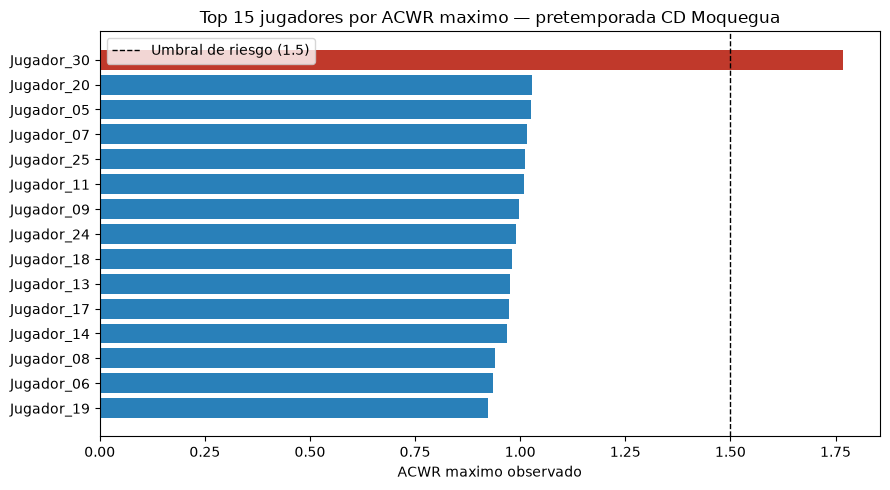

In [5]:
top_acwr = con.execute(
    """
    SELECT jugador, MAX(acwr) AS max_acwr
    FROM acwr_risk
    WHERE historia_suficiente
    GROUP BY jugador
    ORDER BY max_acwr DESC
    LIMIT 15
    """
).df()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#c0392b" if v > 1.5 else "#2980b9" for v in top_acwr["max_acwr"]]
ax.barh(top_acwr["jugador"], top_acwr["max_acwr"], color=colors)
ax.axvline(1.5, color="black", linestyle="--", linewidth=1, label="Umbral de riesgo (1.5)")
ax.set_xlabel("ACWR maximo observado")
ax.set_title("Top 15 jugadores por ACWR maximo — pretemporada CD Moquegua")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/top_acwr.png", dpi=120)
plt.show()

## Limitaciones de esta corrida

- El snapshot de GPS es pretemporada (dic 2025 - ene/feb 2026); la Liga 1 Apertura recien arranca el 02/02/2026, por lo que las semanas de entrenamiento analizadas no se solapan con semanas de partidos. En esta corrida especifica `alerta_combinada` puede dar 0 casos aunque `riesgo_acwr` si detecte jugadores — la logica del flag combinado esta cubierta por tests unitarios y se activaria con datos de una temporada en curso.
- El roster tiene una discontinuidad de nomenclatura de jugador entre el 17 y el 20 de enero de 2026 (ver `docs/data_dictionary.md` si se agrega, o el README): los codigos anonimizados no se mezclan entre ambas convenciones, asi que el ACWR de jugadores que solo aparecen en la segunda ventana parte con menos historial.
- `num_sprints` no existe en el export de Catapult confirmado; se omitio en vez de aproximarlo con una metrica inventada.
- Es un pipeline batch sobre datos historicos, no una integracion en vivo con Catapult ni con el club.